# Validation for the Neutrino Interface

This notebook validates the neutrino interface in different cloelib cosmology backends.
Each backend is validated against their original library.

We also validate that that different backends return the same results for the same neutrino parameters like $\Omega_\nu$ and $N_{\rm eff}$.

For each of the backends, we check the following:
- $H(z)$
- $\chi(z)$
- $P^{\rm lin}(k)$
- $P^{\rm nl}(k)$

Showing the quantities and their relative percent error:  $\delta = \frac{A_{\rm cloelib} - A_{\rm original}}{A_{\rm original}} \times 100\%$

The models we will validate are:
- `mnu = 0.0`, `N_ur = 3.044`, `N_mnu = 0`
- `mnu = 0.12`, `N_ur = 3.044`, `N_mnu = 3` (degenerate neutrinos)
- `mnu = 0.02, 0.04, 0.06`, `N_ur = 3.044`, `N_mnu = 3` (non-degenerate neutrinos)

## Backends validated in this notebook
- cloelib[camb]
- cloelib[class]
- ...

# 

<style>
details summary {
  font-size: 1.25em;    /* roughly H3 size */
  font-weight: bold;
  cursor: pointer;
}
</style>
<details>
<summary><strong>📑 Notebook Table of Contents</strong></summary>

- [Set-up](#Set-up)
  - [Fiducial Cosmology](#fiducial-cosmology)
- [CLASS Validation](#class-validation)
  - [CLASS Set-up](#class-set-up)
  - [cloelib[class] Set-up](#cloelibclass-set-up)
  - [CLASS Validation: $H(z)$](#class-validation-hz)
  - [CLASS Validation: $\chi(z)$](#class-validation-chiz)
  - [CLASS Validation: $P^{lin}(k)$](#class-validation-plink)
  - [CLASS Validation: $P^{nl}(k)$](#class-validation-pnlk)

</details>

# Set-up
This section sets up the notebook, imports the necessary libraries, and defines the fiducial cosmology parameters.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import (
    CAMBBackground,
    CAMBLinearPerturbations,
    CAMBNonLinearPerturbations
)
from cloelib.cosmology.class_cosmology import (
    CLASSBackground,
    CLASSLinearPerturbations,
    CLASSNonLinearPerturbations
)
from cloelib.auxiliary.units import SPEED_OF_LIGHT

c0 = SPEED_OF_LIGHT/1000

# Plot style
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)


## Fiducial Cosmology
- $\Lambda$ CDM
- No massive neutrinos, i.e., $\sum m_\nu = 0$, $N_{\rm eff} = 3.044$, $N_{\rm m\nu} = 0$
- Mead2020 for the non-linear power spectrum

_Same cosmology as in the `validation_ccl.ipynb` notebook._

In [3]:
cosmo_dict = {
    'H0': 67.7,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'Omega_k':0,
    'omch2': 0.25*0.677**2,
    'ombh2': 0.05*0.677**2,
    'w0': -1,
    'wa':0,
    'ns':0.95,
    'As':2e-9,
    'mnu':0.0,
    'nnu':3.044,
    'N_eff':3.044,
    'halofit_version':'mead2020'
}

# Redshift array to compute power spectra and define n(z)'s
zs = np.linspace(0.0, 3., 100) 
# fourier modes
ks = np.logspace(np.log10(1e-4), np.log10(3.0), 100)

# Class Validation

In this section we will validate the CLASS backend for the neutrino interface in `cloelib`.

## Class Set-up

### Model 1 
`mnu = 0.0`, `N_ur = 3.044`, `N_mnu = 0`

In [20]:
from classy import Class

# Linear power spectrum parameters for CLASS
class_fiducial_params = {
    'output': 'mPk,mTk',
    'k_per_decade_for_bao': 70,
    'k_per_decade_for_pk': 10,
    'non linear': 'none',
    'z_max_pk': np.max(zs),
    'P_k_max_1/Mpc': np.max(ks),
    # fiducial cosmology parameters
    'H0': cosmo_dict['H0'],
    'omega_cdm': cosmo_dict['omch2'],
    'omega_b': cosmo_dict['ombh2'],
    'n_s': cosmo_dict['ns'],
    'A_s': cosmo_dict['As'],
    'Omega_k': cosmo_dict['Omega_k'],
    'use_ppf': 'yes',
    'Omega_Lambda': 0.0,
    'w0_fld': cosmo_dict['w0'],
    'wa_fld': cosmo_dict['wa'],
    'N_ur': cosmo_dict['N_eff'],
    'N_ncdm': 0,  # No massive neutrinos
}

# Linear Model 1
results_class_M1 = Class()
results_class_M1.set(class_fiducial_params)
results_class_M1.compute()

# Non-linear power spectrum parameters for CLASS
class_fiducial_nonlinear_params = deepcopy(class_fiducial_params)
class_fiducial_nonlinear_params['non linear'] = 'hmcode'
class_fiducial_nonlinear_params['nonlinear_min_k_max'] = 50
class_fiducial_nonlinear_params['hmcode_tol_sigma'] = 1e-8

# Non-linear Model 1
results_class_M1_nl = Class()
results_class_M1_nl.set(class_fiducial_nonlinear_params)
results_class_M1_nl.compute()


# quantities of interest
class_M1_Hubble = np.array([results_class_M1.Hubble(z) for z in zs]) * c0  # km/s/Mpc
class_M1_chi = np.array([results_class_M1.comoving_distance(z) for z in zs])
class_M1_pk = np.array([[results_class_M1.pk(ki, zi) for ki in ks] for zi in zs])
class_M1_pk_nl = np.array([[results_class_M1_nl.pk(ki, zi) for ki in ks] for zi in zs])


### Model 2
`mnu = 0.12`, `N_ur = 0.0044`, `N_mnu = 3` (degenerate neutrinos)

{'output': 'mPk,mTk',
 'k_per_decade_for_bao': 70,
 'k_per_decade_for_pk': 10,
 'non linear': 'hmcode',
 'z_max_pk': 3.0,
 'P_k_max_1/Mpc': 3.0,
 'H0': 67.7,
 'omega_cdm': 0.11458225000000001,
 'omega_b': 0.022916450000000005,
 'n_s': 0.95,
 'A_s': 2e-09,
 'Omega_k': 0,
 'use_ppf': 'yes',
 'Omega_Lambda': 0.0,
 'w0_fld': -1,
 'wa_fld': 0,
 'N_ur': 3.044,
 'N_ncdm': 0,
 'nonlinear_min_k_max': 50,
 'hmcode_tol_sigma': 1e-08}

## cloelib[class] set-up

### Model 1 
`mnu = 0.0`, `N_ur = 3.044`, `N_mnu = 0`

In [16]:
cloeclass_M1 = CLASSBackground(
    H0=cosmo_dict['H0'], 
    Omega_b0=cosmo_dict['Omega_b'], 
    Omega_cdm0=cosmo_dict['Omega_c'], 
    Omega_k0=cosmo_dict['Omega_k'], 
    As=cosmo_dict['As'], 
    ns=cosmo_dict['ns'], 
    mnu=cosmo_dict['mnu'], 
    w0=cosmo_dict['w0'], 
    wa=cosmo_dict['wa'], 
    N_mnu=0,  # No massive neutrinos
    gamma_MG=0.0
)

# background quantities
cloeclass_M1_Hubble = cloeclass_M1.hubble_parameter(zs)
cloeclass_M1_chi = cloeclass_M1.comoving_distance(zs)

cloeclass_M1_linear = CLASSLinearPerturbations(background=cloeclass_M1, redshifts=zs)
cloeclass_M1_nonlinear = CLASSNonLinearPerturbations(background=cloeclass_M1, 
                                                  redshifts=zs, 
                                                  nonlinear_model='hmcode')

cloeclass_M1_pk = cloeclass_M1_linear.matter_power_spectrum(zs, ks)
cloeclass_M1_pk_nl = cloeclass_M1_nonlinear.matter_power_spectrum(zs, ks)

## CLASS Validation: $H(z)$

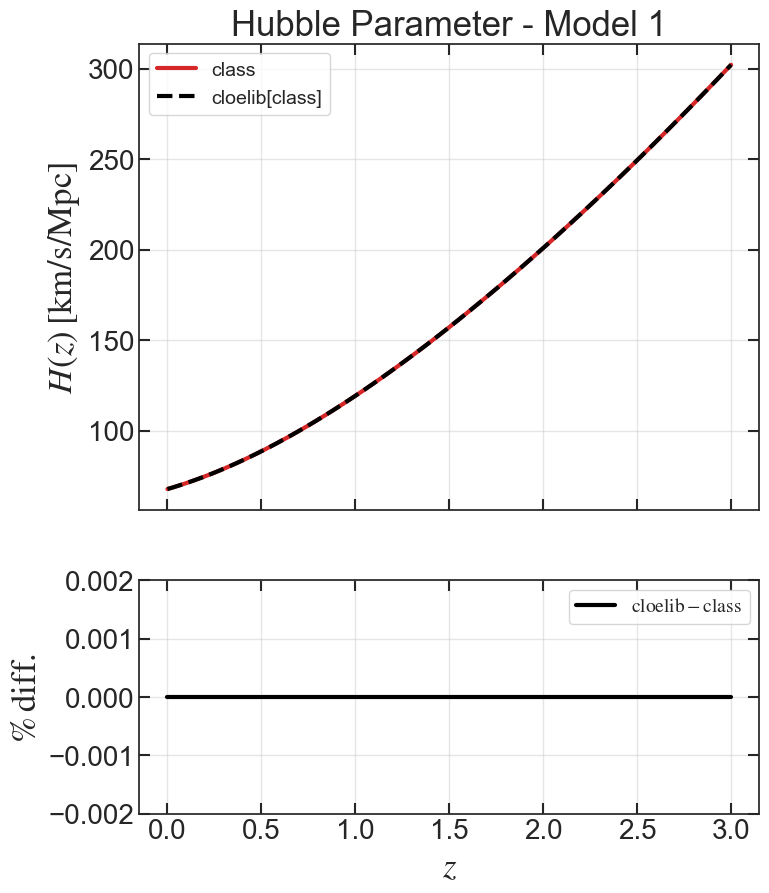

In [37]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title(r'Hubble Parameter - Model 1', fontsize=25)
axs[0].set_ylabel(r'$H_{\rm}(z)\: [\rm{km/s/Mpc}]$', fontsize=25)
axs[0].plot(zs,  class_M1_Hubble, color='tab:red',  label=r'class')
axs[0].plot(zs,  cloeclass_M1_Hubble, color='black', ls='--', label=r'cloelib[class]')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$z$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(zs, (cloeclass_M1_Hubble - class_M1_Hubble)/class_M1_Hubble*100, color='black', ls='-', label=r'$\rm{cloelib-class}$')


axs[1].legend()
# axs[1].set_xscale('log')
axs[1].set_ylim([-0.002, 0.002])
# axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)


## CLASS Validation: $\chi(z)$

/var/folders/zj/nw2dp_t501j_g9h3tl6kybwh0000gn/T/ipykernel_73571/340877507.py:13: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(zs, (cloeclass_M1_chi - class_M1_chi)/class_M1_chi*100, color='black', ls='-', label=r'$\rm{cloelib-class}$')


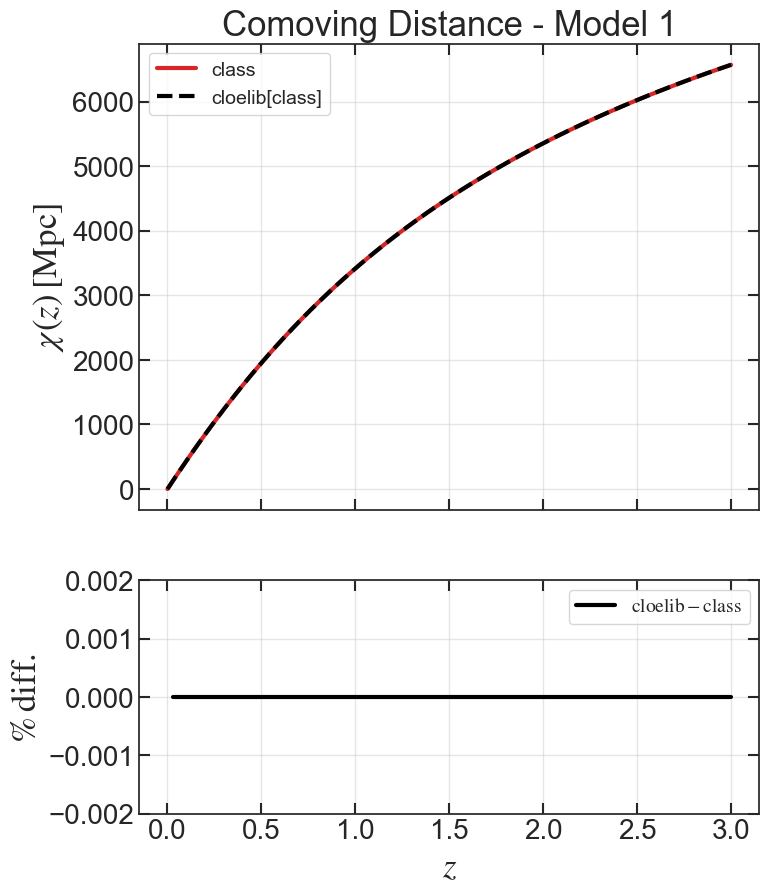

In [53]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title(r'Comoving Distance - Model 1', fontsize=25)
axs[0].set_ylabel(r'$\chi_{\rm}(z)\: [\rm{Mpc}]$', fontsize=25)
axs[0].plot(zs,  class_M1_chi, color='tab:red',  label=r'class')
axs[0].plot(zs,  cloeclass_M1_chi, color='black', ls='--', label=r'cloelib[class]')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$z$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(zs, (cloeclass_M1_chi - class_M1_chi)/class_M1_chi*100, color='black', ls='-', label=r'$\rm{cloelib-class}$')


axs[1].legend()
# axs[1].set_xscale('log')
axs[1].set_ylim([-0.002, 0.002])
# axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)

## CLASS Validation: $P^{lin}(k)$

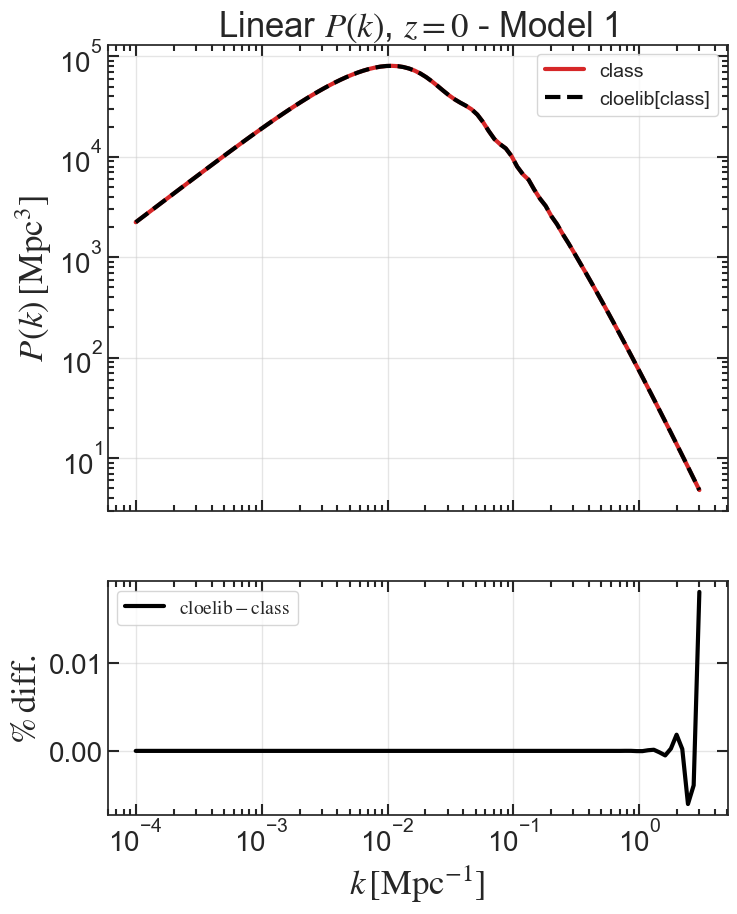

In [51]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title(r'Linear $P(k)$, $z=0$ - Model 1', fontsize=25)
axs[0].set_ylabel(r'$P_{\rm}(k)\: [\rm{Mpc}^3]$', fontsize=25)
axs[0].loglog(ks,  class_M1_pk[0,:], color='tab:red',  label=r'class')
axs[0].loglog(ks,  cloeclass_M1_pk[0,:], color='black', ls='--', label=r'cloelib[class]')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k\,[\rm{Mpc}^{-1}]$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(ks, (cloeclass_M1_pk[0,:] - class_M1_pk[0,:])/class_M1_pk[0,:]*100, color='black', ls='-', label=r'$\rm{cloelib-class}$')


axs[1].legend()
axs[1].set_xscale('log')
#axs[1].set_ylim([-0.002, 0.002])
# axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)

## CLASS Validation: $P^{nl}(k)$

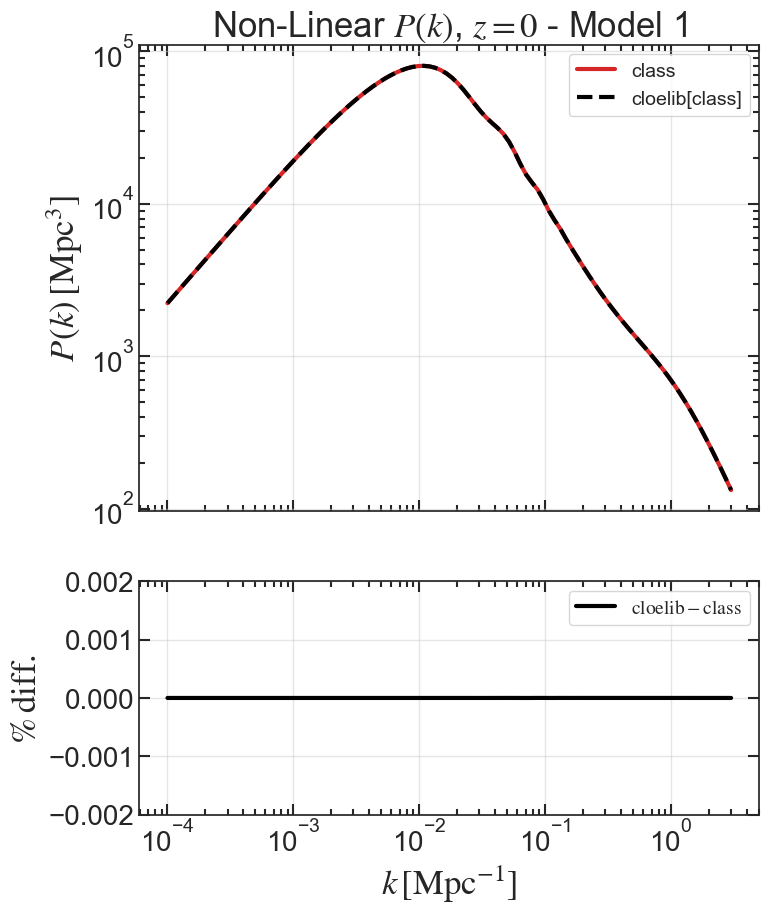

In [55]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title(r'Non-Linear $P(k)$, $z=0$ - Model 1', fontsize=25)
axs[0].set_ylabel(r'$P_{\rm}(k)\: [\rm{Mpc}^3]$', fontsize=25)
axs[0].loglog(ks,  class_M1_pk_nl[0,:], color='tab:red',  label=r'class')
axs[0].loglog(ks,  cloeclass_M1_pk_nl[0,:], color='black', ls='--', label=r'cloelib[class]')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k\,[\rm{Mpc}^{-1}]$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(ks, (cloeclass_M1_pk_nl[0,:] - class_M1_pk_nl[0,:])/class_M1_pk_nl[0,:]*100, color='black', ls='-', label=r'$\rm{cloelib-class}$')


axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_ylim([-0.002, 0.002])
# axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)